This notebook runs CMA's FengYuan-Weather data-driven model, using ECMWF's [open data](https://www.ecmwf.int/en/forecasts/datasets/open-data) dataset and the ONNX weights of [FengYuan-Weather](https://zenodo.org/records/17585603).

## Installed required packages and imports

In [1]:
# Uncomment the lines below to install the required packages
# !pip install -q torch numpy xarray
# !pip install -q earthkit ecmwf-opendata
# !pip install -q onnxruntime onnxruntime-gpu
# !pip install -q ultraplot matplotlib cartopy

In [2]:
import os
from typing import Optional
from collections import defaultdict
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import earthkit.data as ekd
from ecmwf.opendata import Client as OpendataClient
import onnxruntime as ort

import ultraplot as uplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Define functions for data downloading, model loading and inference

In [3]:
def get_open_data(init_date, param, levelist=[]):
    """https://huggingface.co/ecmwf/aifs-single-1.0/blob/main/run_AIFS_v1.ipynb"""
    fields = defaultdict(list)
    # Get the data for the current date and the previous date
    for date in [init_date - timedelta(hours=6), init_date]:
        data = ekd.from_source("ecmwf-open-data", date=date, param=param, levelist=levelist)
        for f in data:
            # Open data is between -180 and 180, we need to shift it to 0-360
            assert f.to_numpy().shape == (721, 1440)
            values = np.roll(f.to_numpy(), -f.shape[1] // 2, axis=1)
            # Add the values to the list
            name = f"{f.metadata('param')}{f.metadata('levelist')}" if levelist else f.metadata("param")
            fields[name].append(values)

    # Create a single matrix for each parameter
    for param, values in fields.items():
        fields[param] = np.stack(values)

    return fields

def normalize_pair(prev_frame: np.ndarray, curr_frame: np.ndarray,
                    mean: np.ndarray, std: np.ndarray,
                    dtype: np.dtype) -> np.ndarray:
    """normalize input data pair"""
    stacked = np.stack([prev_frame, curr_frame], axis=0)
    normed = (stacked - mean) / std
    x = normed[None, ...]
    return x.astype(dtype, copy=False)

def denorm(y: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    """denormalize output data"""
    return (y * std + mean).astype(np.float32, copy=False)

def get_available_providers():
    """get available execution providers"""
    avail = ort.get_available_providers()
    pick = [p for p in ["CUDAExecutionProvider", "CPUExecutionProvider"] if p in avail]
    return pick if pick else avail

def get_io_info(session):
    """get model input and output information"""
    typemap = {
        "tensor(float16)": np.float16,
        "tensor(float)":   np.float32,
        "tensor(double)":  np.float64,
        "tensor(int64)":   np.int64,
        "tensor(int32)":   np.int32,
        "tensor(int16)":   np.int16,
        "tensor(int8)":    np.int8,
        "tensor(uint8)":   np.uint8,
        "tensor(bool)":    np.bool_,
    }
    inp = session.get_inputs()[0]
    out = session.get_outputs()[0]
    return inp.name, typemap.get(inp.type, np.float32), typemap.get(out.type, np.float32)

def ensure_var_hw(y: np.ndarray) -> np.ndarray:
    """ensure output shape is (70, 721, 1440)"""
    yy = np.asarray(y)
    while yy.ndim > 3:
        if yy.shape[0] == 1:
            yy = yy[0]
        else:
            break
    assert yy.ndim == 3, f"Unexpected output shape after squeeze: {yy.shape}"
    assert yy.shape[0] == 70, f"Channel/variable dimension != 70: {yy.shape}"
    return yy

def run_inference(session, in_name: str, in_dtype: np.dtype,
                prev_frame: np.ndarray, curr_frame: np.ndarray,
                mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    """run model inference"""
    x = normalize_pair(prev_frame, curr_frame, mean, std, in_dtype)
    y_list = session.run(None, {in_name: x})
    y = y_list[0]
    y = ensure_var_hw(y)
    y = denorm(y, mean, std)
    return y

def generate_output_filename(step: int, when: Optional[datetime], model_type: str,
                            filename_format: str="%Y%m%d%H%M%S.nc", filename_prefix: str="",
                            filename_suffix: str="") -> str:
        """generate output filename"""
        if when is not None:
            time_str = when.strftime(filename_format)
            
            if not time_str.endswith('.nc'):
                time_str += '.nc'
            out_name = f"{filename_prefix}{time_str}{filename_suffix}"
        else:
            out_name = f"{filename_prefix}{model_type}_step{step:02d}.nc{filename_suffix}"
        
        return out_name

def save_step_to_netcdf(y_var_hw: np.ndarray, out_path: str, when: Optional[datetime], var_names: list,
                        engine: str = "netcdf4", encoding: dict = None) -> None:
        """save single step prediction to NetCDF file"""

        if encoding is None:
            encoding = {
            "forecast": {
                "zlib": True if engine == "netcdf4" else False,
                "complevel": 9,
                "dtype": "float32",
                "chunksizes": (1, 10, 180, 180)
                    }
                }

        variable = np.array(var_names, dtype=object)
        y_coords = np.arange(y_var_hw.shape[1], dtype=np.int32)
        x_coords = np.arange(y_var_hw.shape[2], dtype=np.int32)

        da = xr.DataArray(
            y_var_hw[None, ...],  #add time dim
            dims=("time", "variable", "y", "x"),
            coords={
                "time": [np.datetime64(when) if when is not None else np.datetime64("NaT")],
                "variable": variable,
                "y": y_coords,
                "x": x_coords
            },
            name="forecast",
            attrs={"description": "Autoregressive forecast (one step)", "units": "SI/mixed"}
        )
        ds = xr.Dataset({"forecast": da})
        ds.to_netcdf(out_path, format="NETCDF4", engine=engine, encoding=encoding)
        ds.close()

def run_forecast(session_model, prev: np.ndarray, curr: np.ndarray, mean: np.ndarray, std: np.ndarray,
                var_names: list, t: Optional[datetime] = None, step_hours: int = 6, save_dir: str = "forecasts",
                save_pred: bool = False, model_type: str = "short"):

    if not os.path.exists(save_dir):
        os.makedirs(save_dir, exist_ok=True)

    base_hour = 0 if model_type == "short" else 120
    in_name_s, in_dtype_s, _ = get_io_info(session_model)
    predictions = []
    for i in range(1, 20 + 1):
        y = run_inference(session_model, in_name_s, in_dtype_s,
            prev, curr, mean, std
        )

        if save_pred:
            t = None if t is None else (t + timedelta(hours=step_hours))
            out_name = generate_output_filename(i, t, "short")
            out_path = os.path.join(save_dir, out_name)
        
            save_step_to_netcdf(y, out_path, t, var_names)
            print(f"{base_hour + i*step_hours:03d} hours forecast -> {out_path}")

        prev, curr = curr, y
        predictions.append(y)
    
    predictions = np.stack(predictions)

    return predictions, prev, curr, t

## Download Initial Conditions from ECMWF Open Data

Define the initial date

In [4]:
init_date = OpendataClient().latest()
print("Initial date is", init_date)

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


Initial date is 2025-12-21 00:00:00


List of parameters to download from ECMWF open data for inference

In [5]:
params_sfc = ["2t", "10u", "10v", "msl", "tp"]
params_pl = ["t", "u", "v", "gh", "q"]
pres_levels = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50]

Get input fileds of surface and pressure levels

In [6]:
input_fields = dict()

In [7]:
# add surface fields
input_fields.update(get_open_data(init_date, param=params_sfc))

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


In [8]:
# add pressure level fields
input_fields.update(get_open_data(init_date, param=params_pl, levelist=pres_levels))

In [9]:
# Transform GH to Z
for level in pres_levels:
    gh = input_fields.pop(f"gh{level}")
    input_fields[f"z{level}"] = gh * 9.80665

In [10]:
# the input/output list of variable names for the FengYuan-Weather model
var_names = [
            't50','u50','v50','z50','q50','t100','u100','v100','z100','q100','t150','u150','v150','z150','q150',
            't200','u200','v200','z200','q200','t250','u250','v250','z250','q250','t300','u300','v300','z300','q300',
            't400','u400','v400','z400','q400','t500','u500','v500','z500','q500','t600','u600','v600','z600','q600',
            't700','u700','v700','z700','q700','t850','u850','v850','z850','q850','t925','u925','v925','z925','q925',
            't1000','u1000','v1000','z1000','q1000','2t','10u','10v','msl','tp'
        ]

In [11]:
input_state = dict(date=init_date, fields=input_fields)
# reorder the input fields to match the variable names
ordered_input_state = {k: input_state['fields'][k] for k in var_names}

## Load the model weights and run forecast

Load the short- and medium-range ONNX weights of FengYuan-Weather model

Note: Before loading the model, please download the ONNX weights of [FengYuan-Weather](https://zenodo.org/records/17585603) and place them in the `data/ckpts` directory.

In [12]:
session_short = ort.InferenceSession('data/ckpts/fengyuan_short.onnx', providers=get_available_providers())
session_medium = ort.InferenceSession('data/ckpts/fengyuan_medium.onnx', providers=get_available_providers())

2025-12-21 16:11:42.394678947 [W:onnxruntime:, transformer_memcpy.cc:83 ApplyImpl] 96 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
2025-12-21 16:11:44.882517379 [W:onnxruntime:, transformer_memcpy.cc:83 ApplyImpl] 96 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.


In [13]:
# stack the input fields to match the variable names
input_frames = np.stack(list(ordered_input_state.values()))
prev_frame = input_frames[:, 0]
curr_frame = input_frames[:, 1]
# load the mean and std of the input fields
mean = np.load('data/mean-1979-2019.npy')
std = np.load('data/std-1979-2019.npy')

Define the parameters to save the predictions of FengYuan-Weather model

In [14]:
save_pred = False
save_dir = "forecasts"

Run the short- and medium- range forecast

In [15]:
# run the short-range forecast
short_pred, short_prev, short_curr, t = run_forecast(session_short, prev_frame, curr_frame, mean, std, var_names,
    t=init_date, save_pred=save_pred, save_dir=save_dir, model_type="short")

In [16]:
# run the medium-range forecast
medium_pred, medium_prev, medium_curr, t = run_forecast(session_medium, short_prev, short_curr, mean, std, var_names,
    t=init_date, save_pred=save_pred, save_dir=save_dir, model_type="medium")

## Visualize the prediction

In [17]:
lon = np.linspace(0, 360, 1440)
lat = np.linspace(90, -90, 721)
lon, lat = np.meshgrid(lon, lat)

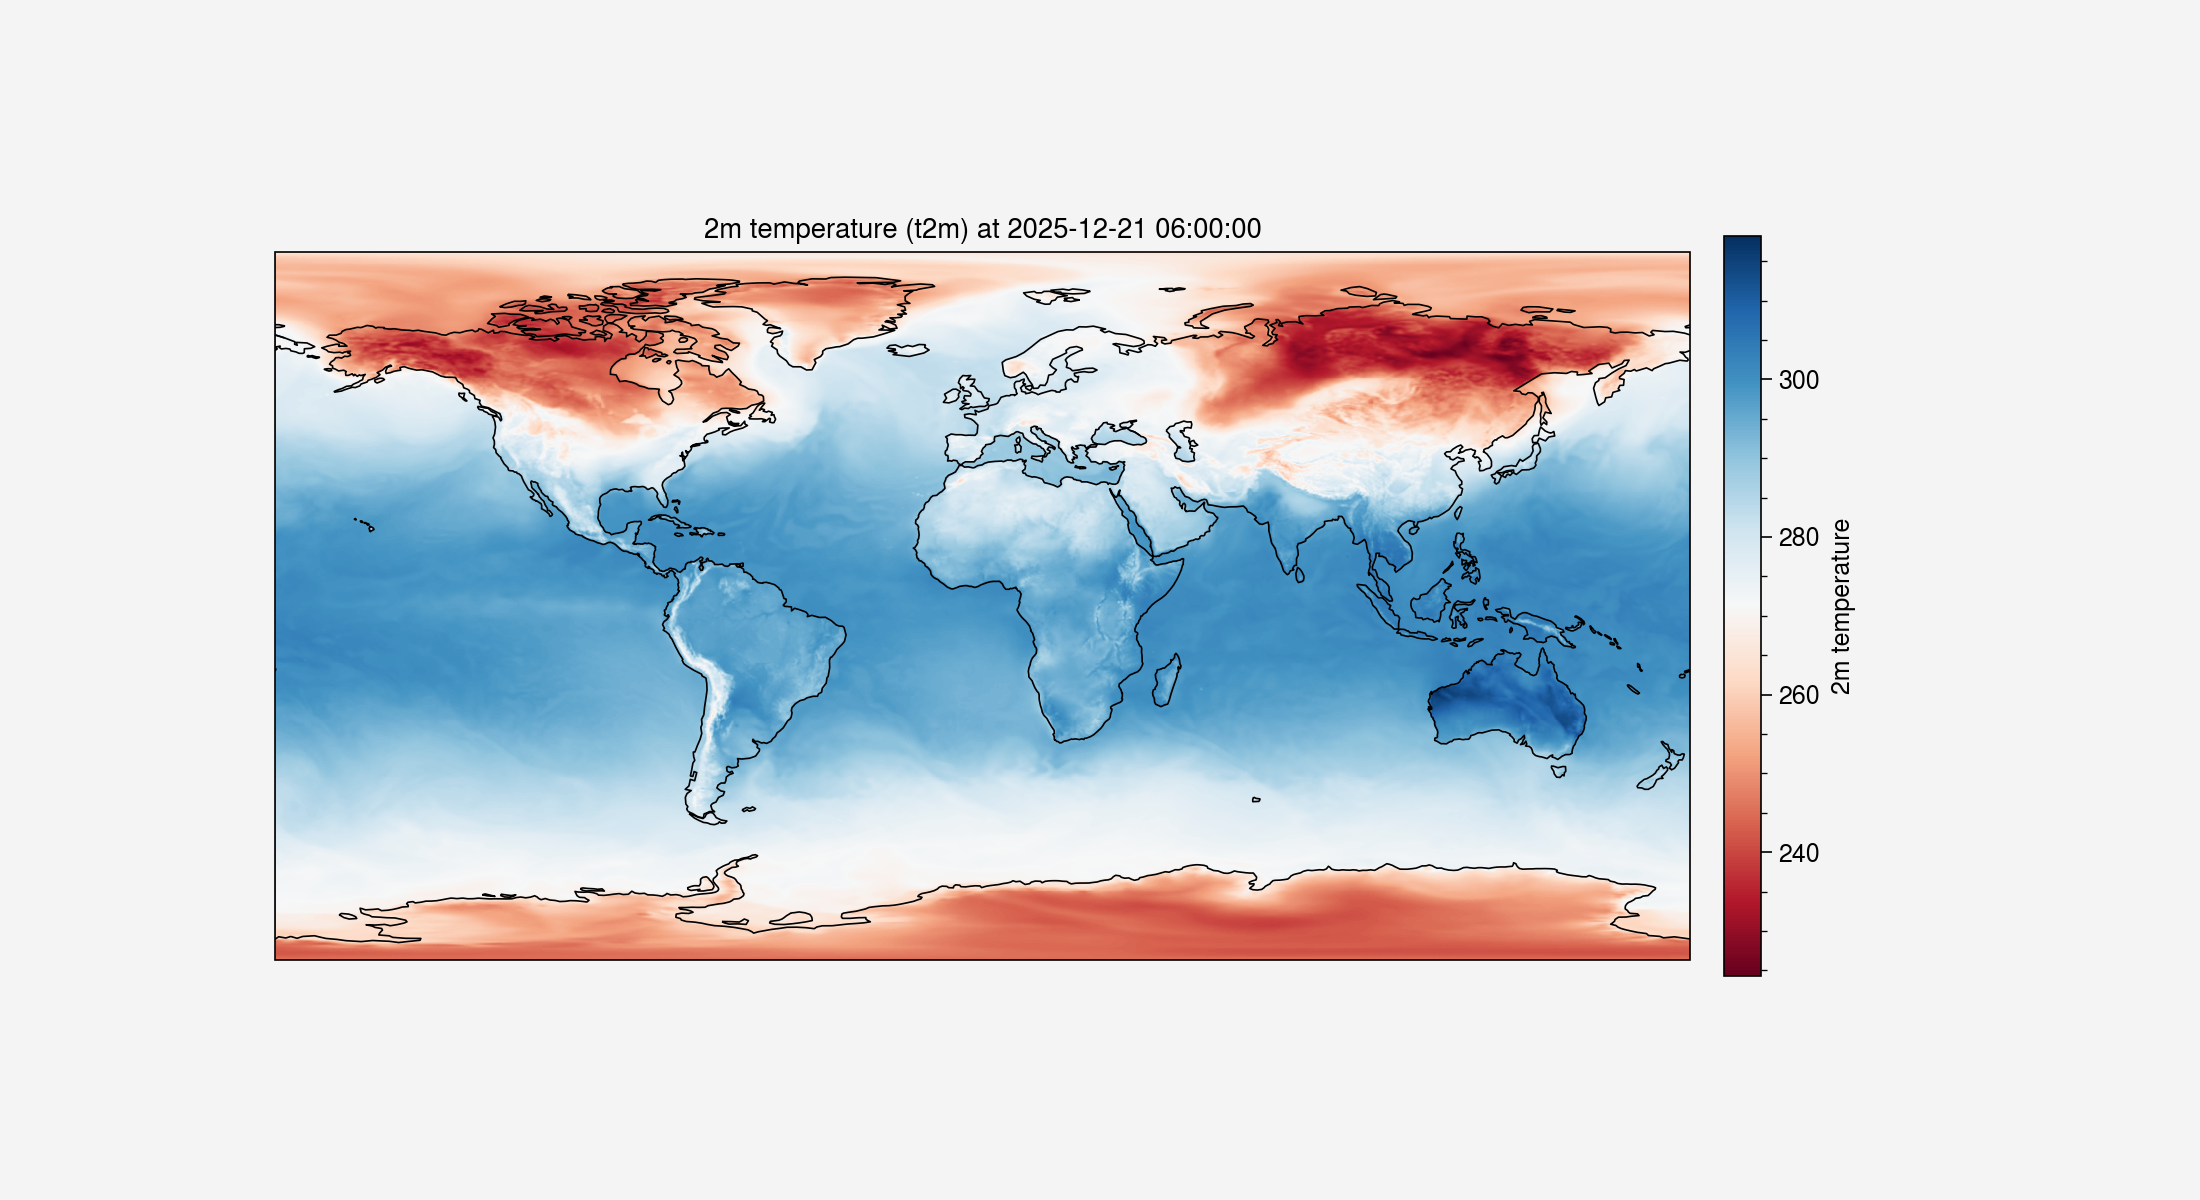

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()})

contour = ax.pcolormesh(lon, lat, short_pred[0, -5], cmap="RdBu")
cbar = fig.colorbar(contour, ax=ax, orientation="vertical", shrink=0.7, pad=0.02, label="2m temperature")

ax.coastlines()

plt.title("2m temperature (t2m) at {}".format(input_state["date"] + timedelta(hours=6)))

plt.show()